# mlxops-aug Demo

Visualises the effect of augmentation methods on 8 ImageNet (Imagenette) images:

- **CutMix** — pastes a random rectangular patch from one image onto another
- **MixUp** — pixel-wise linear interpolation between two images
- **CutMixUp** — randomly picks one of the above each batch
- **PuzzleMix** — saliency-guided mixing with optimal transport

## Setup

In [1]:
import torch
from mlxops_aug import CutMixUp
from mlxops_utils import denormalize

if torch.cuda.is_available():
    DEVICE = "cuda"
elif torch.backends.mps.is_available():
    DEVICE = "mps"
else:
    DEVICE = "cpu"

NUM_CLASSES = 200  # Tiny-ImageNet has 200 classes
N = 8

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

print(f"Device: {DEVICE}")

Device: mps


## Dataset — Tiny-ImageNet (8 images via streaming)

In [2]:
import itertools
import torchvision.transforms as transforms
from datasets import load_dataset

transform = transforms.Compose([
    transforms.Resize(64),
    transforms.CenterCrop(64),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

# Stream just N images — no full dataset download required
# zh-plus/tiny-imagenet: 200-class ImageNet subset, 64x64, Parquet format, no auth needed
stream = load_dataset("zh-plus/tiny-imagenet", split="train", streaming=True)
samples = list(itertools.islice(stream, N))

x_batch = torch.stack([transform(s["image"].convert("RGB")) for s in samples]).to(DEVICE)
y_batch = torch.tensor([s["label"] for s in samples]).to(DEVICE)

print(f"Batch: {x_batch.shape}")
print("Labels:", y_batch.tolist())

Batch: torch.Size([8, 3, 64, 64])
Labels: [0, 0, 0, 0, 0, 0, 0, 0]


## Visualisation Helper

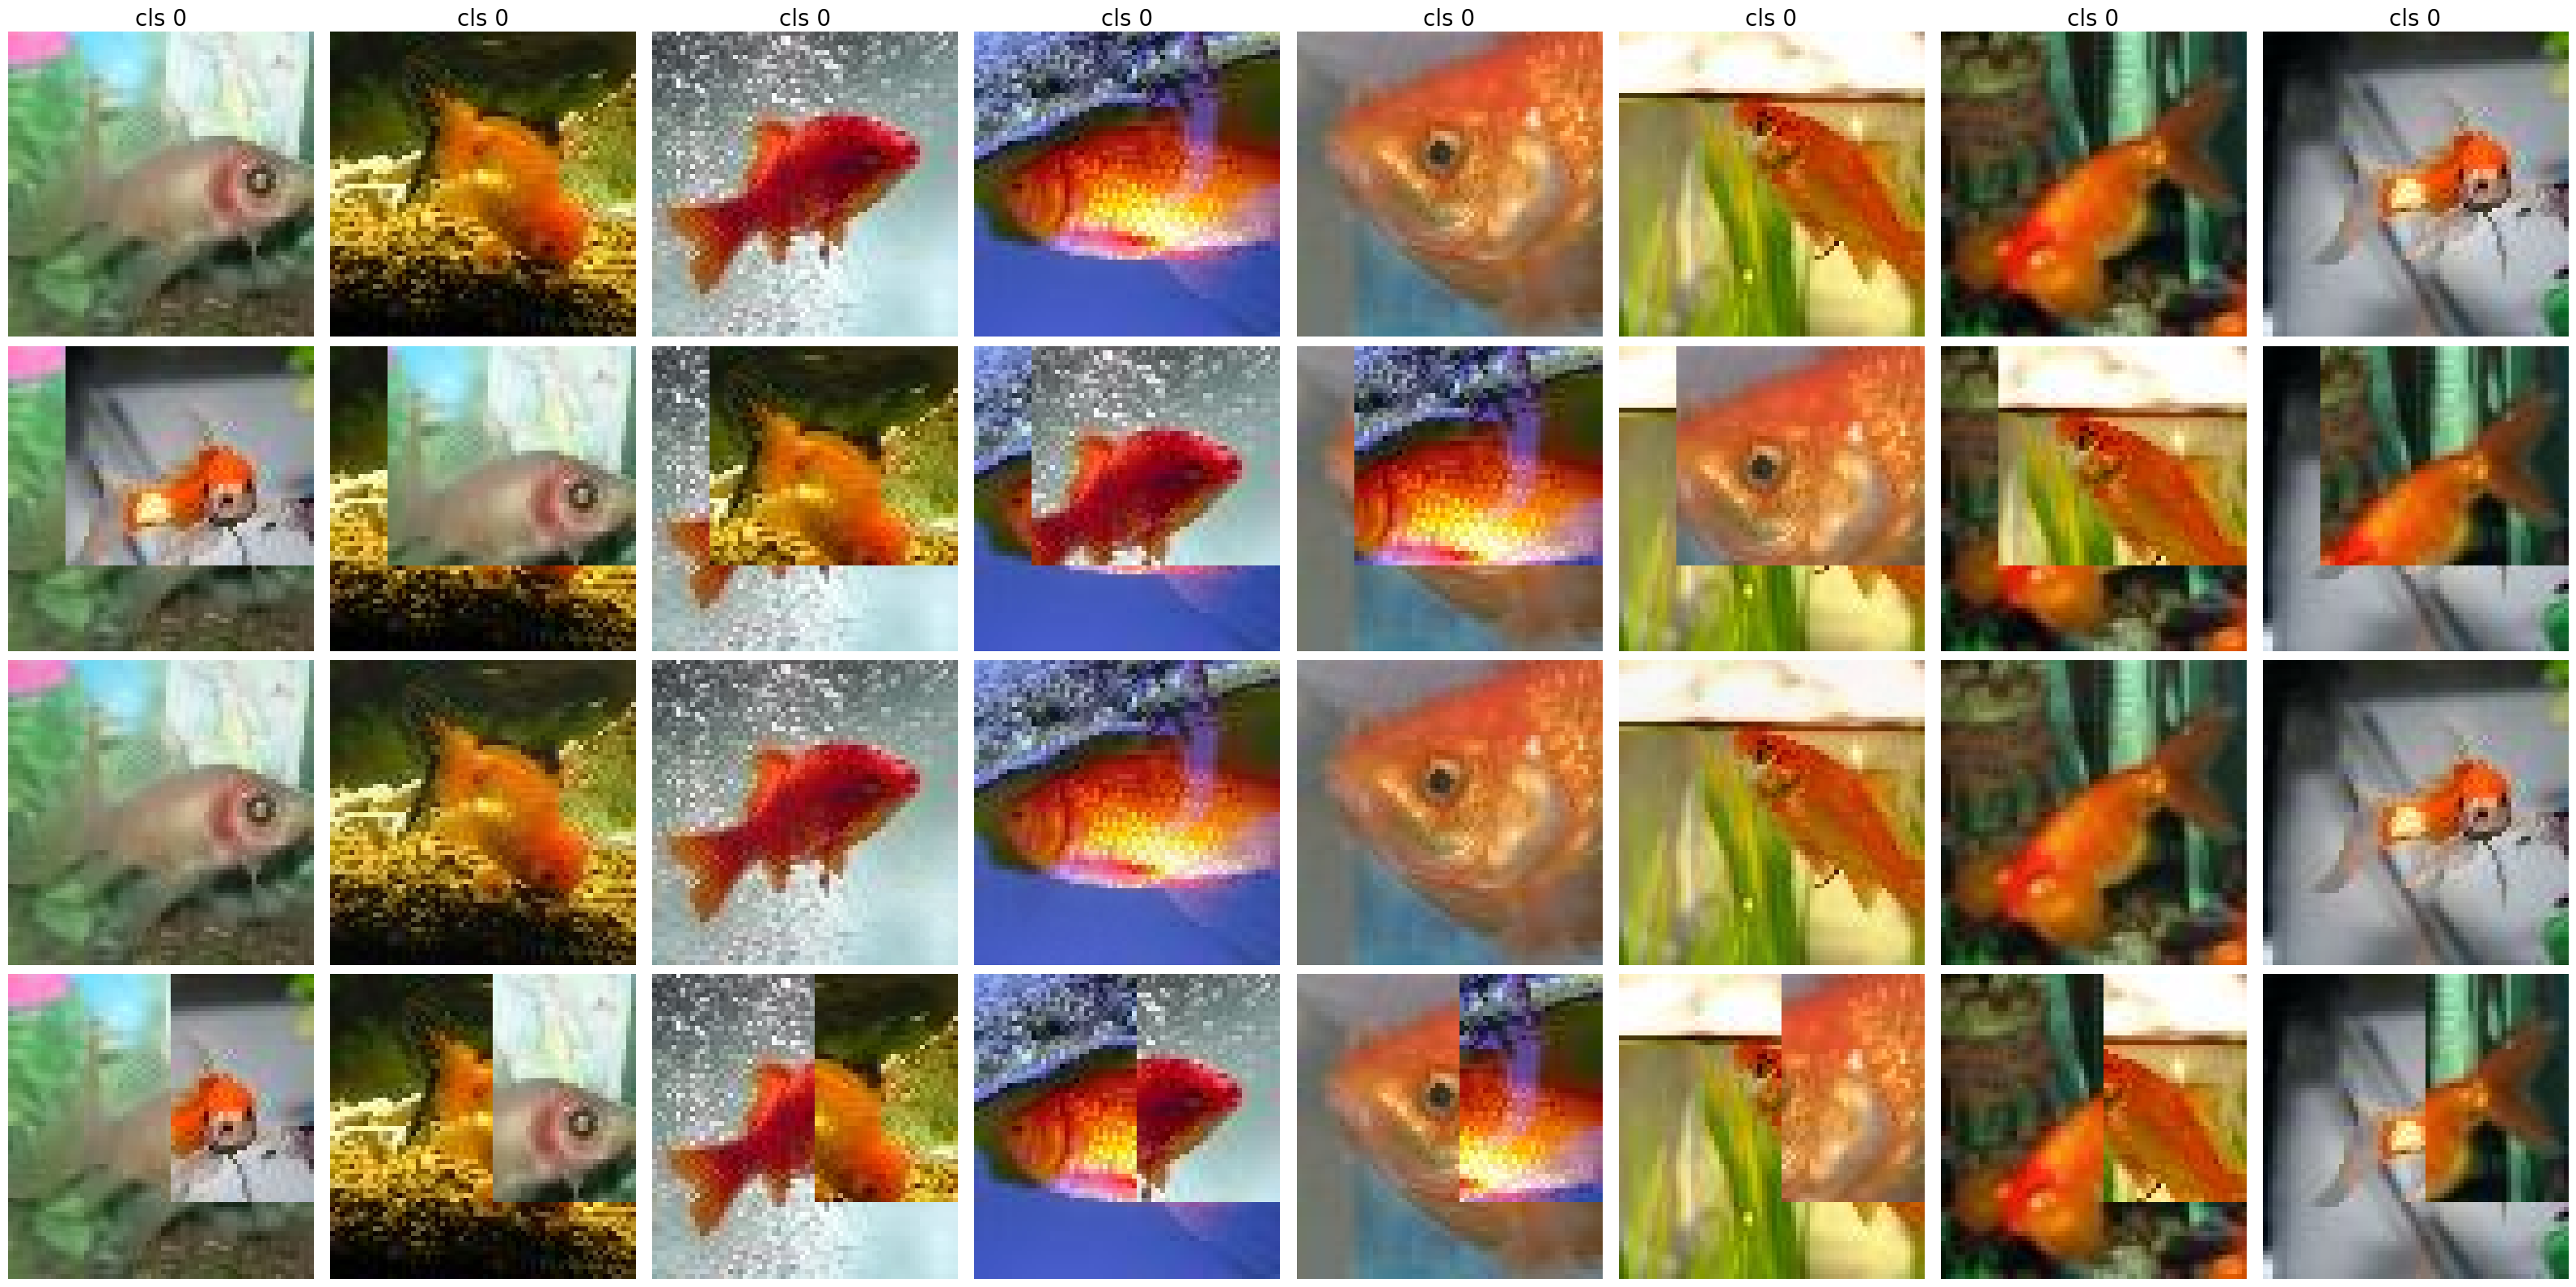

In [3]:
from mlxops_utils import denormalize
from mlxops_utils.plotting_utils import plot_hor

def to_hwc(images):
    imgs = denormalize(images.cpu(), IMAGENET_MEAN, IMAGENET_STD).clamp(0, 1)
    return [img.permute(1, 2, 0).numpy() for img in imgs]

def apply_aug(aug, x, y):
    result = aug(x.clone(), y.clone())
    return aug.get_x_y(result)

cutmix_aug   = CutMixUp(num_classes=NUM_CLASSES, config={"use_cutmix": True,  "use_mixup": False, "prob": 1.0})
mixup_aug    = CutMixUp(num_classes=NUM_CLASSES, config={"use_cutmix": False, "use_mixup": True,  "prob": 1.0})
cutmixup_aug = CutMixUp(num_classes=NUM_CLASSES, config={"use_cutmix": True,  "use_mixup": True,  "prob": 1.0})

x_cutmix,   _ = apply_aug(cutmix_aug,   x_batch, y_batch)
x_mixup,    _ = apply_aug(mixup_aug,    x_batch, y_batch)
x_cutmixup, _ = apply_aug(cutmixup_aug, x_batch, y_batch)

col_titles = [f"cls {y_batch[j].item()}" for j in range(N)]

plot_hor(
    [to_hwc(x_batch),
     to_hwc(x_cutmix),
     to_hwc(x_mixup),
     to_hwc(x_cutmixup)],
    rows=4, columns=N,
    subplot_titles=col_titles,
    idx=["Original", "CutMix", "MixUp", "CutMixUp"],
)
print()


## PuzzleMix

PuzzleMix uses saliency maps (model gradients w.r.t. the input) to guide mixing —
salient regions from each image are preserved in the final blend.

> Requires `pip install "mlxops-aug[puzzlemix]"`

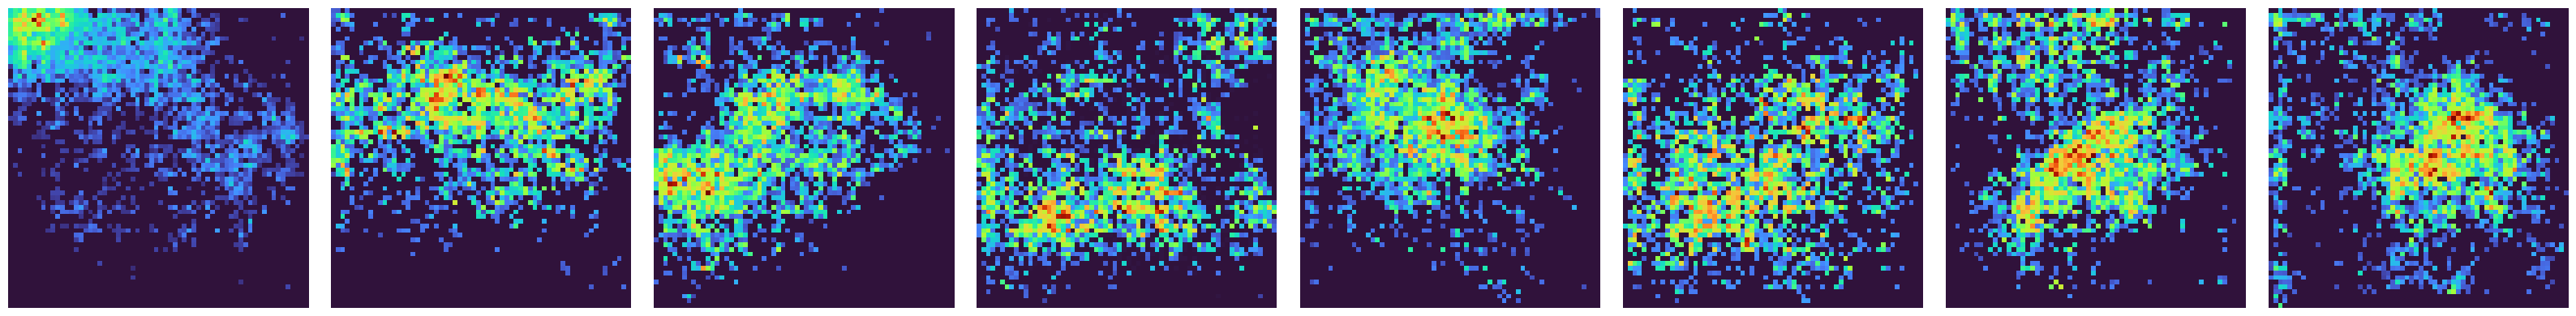

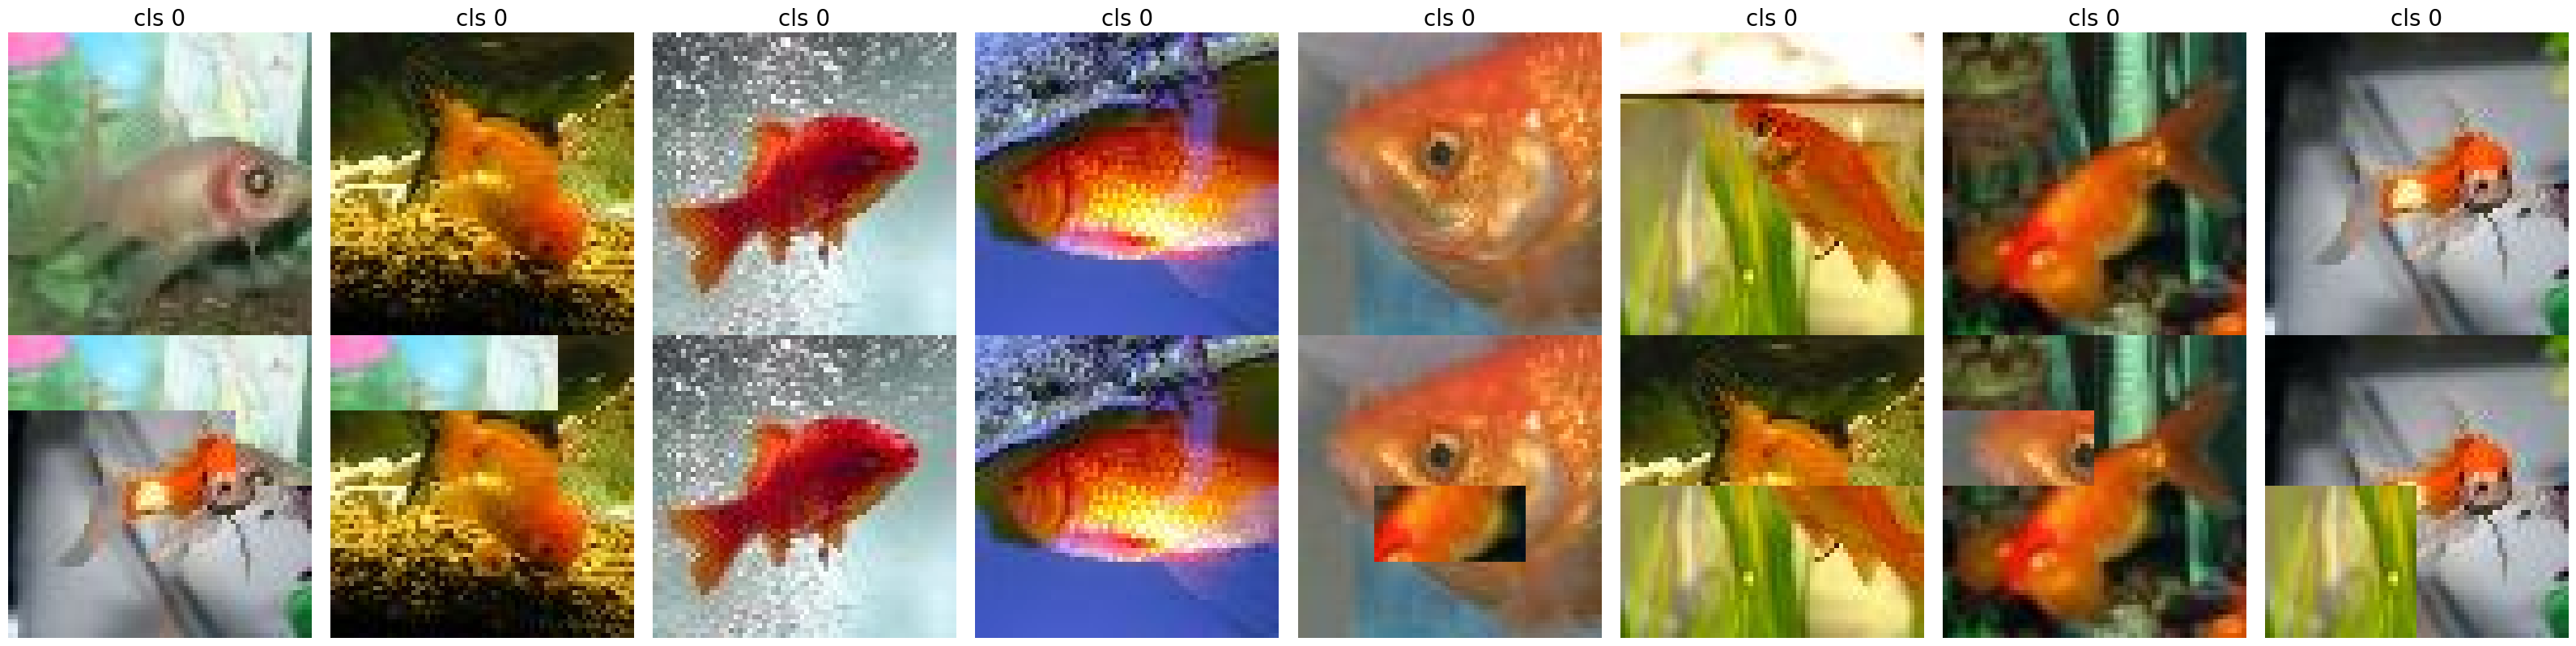

In [4]:
from mlxops_aug import PuzzleMix
import torchvision.models as tv_models

backbone = tv_models.resnet50(weights=tv_models.ResNet50_Weights.DEFAULT)
backbone = backbone.to(DEVICE).eval()

puzzle_aug = PuzzleMix(
    num_classes=NUM_CLASSES,
    config={
        "block_num": 4,   # 4x4=16 patches, more visible puzzle effect
        "transport": True,
        "beta": 1.2,
        "gamma": 0.5,
        "eta": 0.2,
        "prob": 1.0,
        "debug": True,
        "saliency_conf": {
            "method": "guided_absolute_grad",
            "method_kwargs": {
                "th": 0.75
            }
        }
    },
)

x_puzzle, (ya, yb, lam) = puzzle_aug.aug(x_batch, y_batch, backbone)

plot_hor(
    [to_hwc(x_batch), to_hwc(x_puzzle)],
    rows=2, columns=N,
    subplot_titles=col_titles,
    idx=["Original", "Saliency", "PuzzleMix"],
)
print()


### Verify PuzzleMix x–y correspondence

For each augmented image, show: **Image A | Image B (mixed in) | Result**, with the `lam` mixing ratio and label check.

✓ ya == y_batch
✓ lam in [0,1]: [0.31 0.81 1.   1.   0.88 0.5  0.88 0.75]

Per-image breakdown:
  img[0]  ya=  0  yb=  0  lam=0.312  partner_in_batch=0  top2_soft=[1.0, 0.0]
  img[1]  ya=  0  yb=  0  lam=0.812  partner_in_batch=0  top2_soft=[1.0, 0.0]
  img[2]  ya=  0  yb=  0  lam=1.000  partner_in_batch=0  top2_soft=[1.0, 0.0]
  img[3]  ya=  0  yb=  0  lam=1.000  partner_in_batch=0  top2_soft=[1.0, 0.0]
  img[4]  ya=  0  yb=  0  lam=0.875  partner_in_batch=0  top2_soft=[1.0, 0.0]
  img[5]  ya=  0  yb=  0  lam=0.500  partner_in_batch=0  top2_soft=[1.0, 0.0]
  img[6]  ya=  0  yb=  0  lam=0.875  partner_in_batch=0  top2_soft=[1.0, 0.0]
  img[7]  ya=  0  yb=  0  lam=0.750  partner_in_batch=0  top2_soft=[1.0, 0.0]


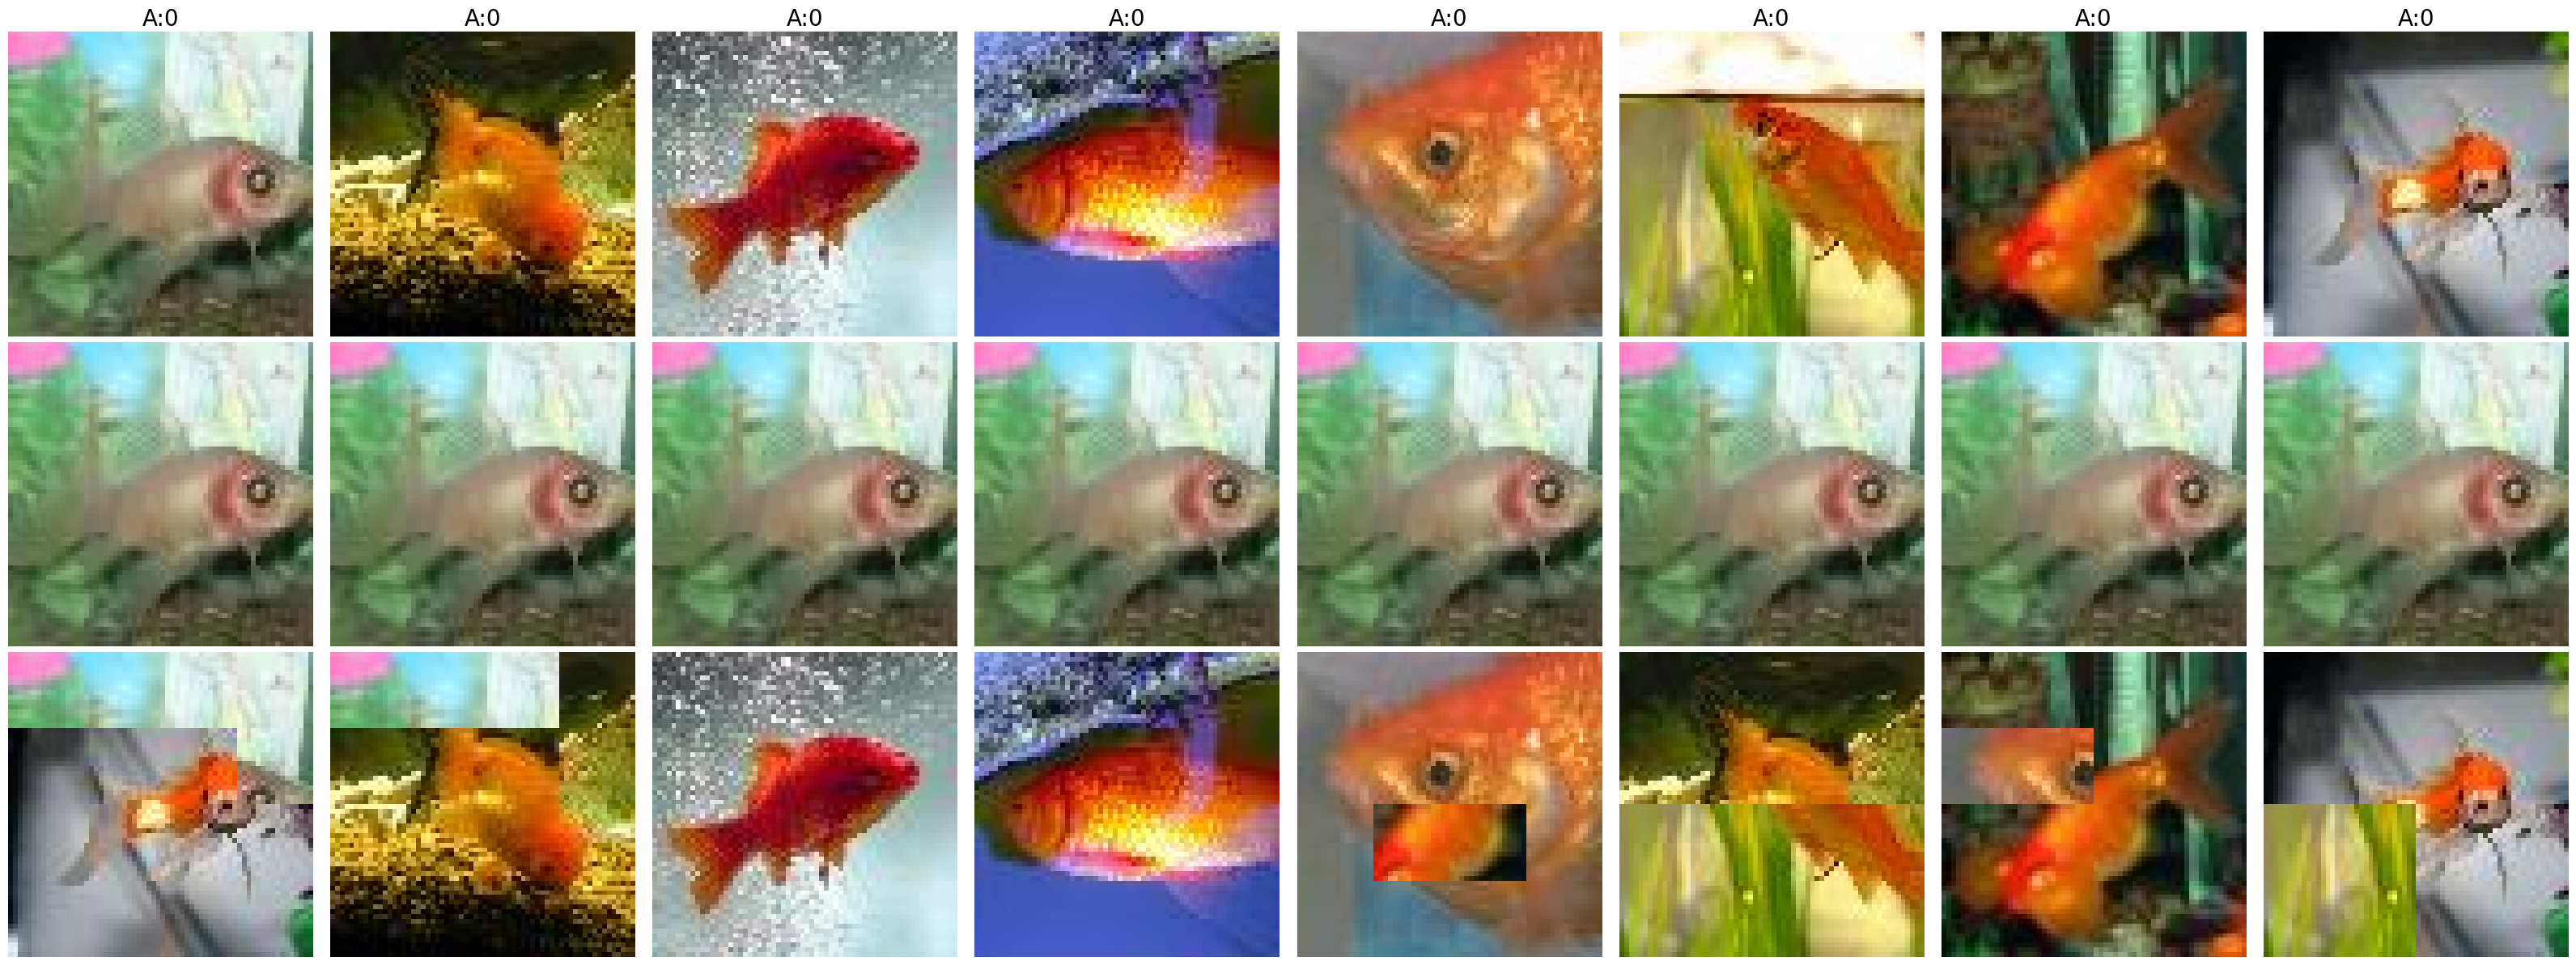

In [5]:
import torch.nn.functional as F

# ya should equal the original y_batch exactly
assert (ya == y_batch).all(), "ya does not match y_batch!"
print("✓ ya == y_batch")

# lam should be in [0, 1]
assert lam.min() >= 0 and lam.max() <= 1, f"lam out of range: {lam}"
print(f"✓ lam in [0,1]: {lam.cpu().numpy().round(2)}")

# Verify soft label = lam * one_hot(ya) + (1-lam) * one_hot(yb)
oh_a  = F.one_hot(ya,  NUM_CLASSES).float()
oh_b  = F.one_hot(yb,  NUM_CLASSES).float()
ll    = lam.reshape(-1, 1)
expected_y = oh_a * ll + oh_b * (1 - ll)

# Show per-image: Image A | Image B (partner) | PuzzleMix result | lam
print("\nPer-image breakdown:")
for i in range(N):
    # Find the partner in x_batch by matching yb[i]; pick first match
    partner_mask = (y_batch == yb[i])
    partner_idx  = partner_mask.nonzero(as_tuple=True)[0][0].item()
    print(
        f"  img[{i}]  ya={ya[i].item():3d}  yb={yb[i].item():3d}"
        f"  lam={lam[i].item():.3f}  partner_in_batch={partner_idx}"
        f"  top2_soft={expected_y[i].topk(2).values.tolist()}"
    )

# Visual: for each image, show [A, B(partner), result] as 3-row grid
row_a      = to_hwc(x_batch)
row_result = to_hwc(x_puzzle)

# Build partner row: x_batch[partner_idx] for each i
partners  = torch.stack([
    x_batch[(y_batch == yb[i]).nonzero(as_tuple=True)[0][0]] for i in range(N)
])
row_b = to_hwc(partners)

plot_hor(
    [row_a, row_b, row_result],
    rows=3, columns=N,
    subplot_titles=[f"A:{ya[j].item()}" for j in range(N)],
    idx=["Image A", "Image B (mixed in)", "PuzzleMix result"]
)
print()

## ResizeMix

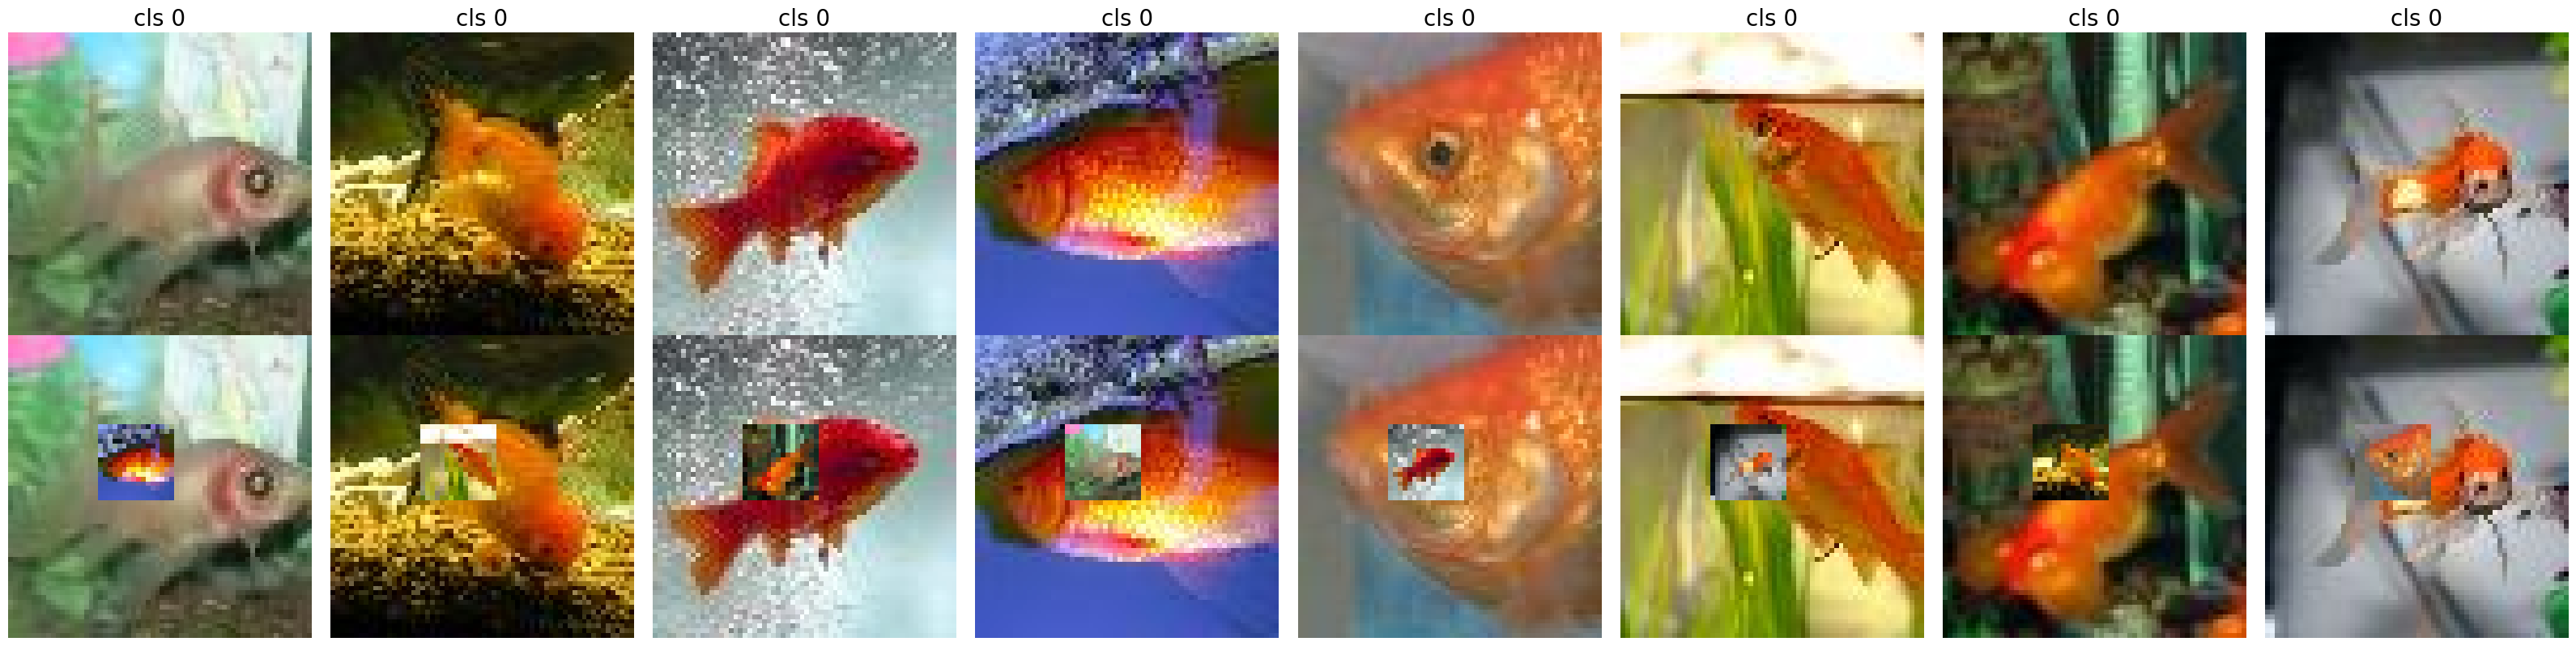

In [6]:
from mlxops_aug import ResizeMix

resizemix_aug   = ResizeMix(num_classes=NUM_CLASSES, config={"prob": 1.0})

x_resizemix,   y_resizemix = apply_aug(resizemix_aug,   x_batch, y_batch)

plot_hor(
    [to_hwc(x_batch),
     to_hwc(x_resizemix)],
    rows=2, columns=N,
    subplot_titles=col_titles,
    idx=["Original", "ResizeMix"],
)
print()

## ReMix

In [7]:
import numpy as np
import matplotlib.pyplot as plt

def generate_long_tail_targets(num_classes=200, total_samples=100000, decay_factor=0.99):
    """
    生成长尾分布的targets
    
    Args:
        num_classes: 类别数量
        total_samples: 总样本数
        decay_factor: 衰减因子，控制长尾程度
    """
    # 计算每个类的权重（指数衰减）
    weights = np.array([decay_factor ** i for i in range(num_classes)])
    
    # 归一化权重
    weights = weights / weights.sum()
    
    # 计算每个类的样本数量
    samples_per_class = (weights * total_samples).astype(int)
    
    # 确保总数正确
    diff = total_samples - samples_per_class.sum()
    samples_per_class[:diff] += 1
    
    # 生成targets
    targets = []
    for class_id in range(num_classes):
        targets.extend([class_id] * samples_per_class[class_id])
    
    return targets, samples_per_class

# 生成长尾targets
targets, counts = generate_long_tail_targets()
print(f"总样本数: {len(targets)}")
print(f"前10个类的样本数: {counts[:10]}")
print(f"后10个类的样本数: {counts[-10:]}")
print(f"targets前20个: {targets[:20]}")


总样本数: 100000
前10个类的样本数: [1155 1144 1132 1121 1110 1099 1088 1077 1066 1055]
后10个类的样本数: [171 169 167 165 164 162 161 159 157 156]
targets前20个: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]


ReMix: scanning labels: 100%|██████████| 391/391 [00:10<00:00, 35.81it/s]


Label count: Counter({0: 1155, 1: 1144, 2: 1132, 3: 1121, 4: 1110, 5: 1099, 6: 1088, 7: 1077, 8: 1066, 9: 1055, 10: 1045, 11: 1034, 12: 1024, 13: 1014, 14: 1004, 15: 994, 16: 984, 17: 974, 18: 964, 19: 954, 20: 945, 21: 935, 22: 926, 23: 917, 24: 908, 25: 899, 26: 890, 27: 881, 28: 872, 29: 863, 30: 855, 31: 846, 32: 838, 33: 829, 34: 821, 35: 813, 36: 805, 37: 797, 38: 789, 39: 781, 40: 773, 41: 765, 42: 758, 43: 750, 44: 743, 45: 735, 46: 728, 47: 720, 48: 713, 49: 706, 50: 699, 51: 692, 52: 685, 53: 678, 54: 672, 55: 665, 56: 658, 57: 652, 58: 645, 59: 639, 60: 632, 61: 626, 62: 620, 63: 614, 64: 607, 65: 601, 66: 595, 67: 589, 68: 583, 69: 578, 70: 572, 71: 566, 72: 561, 73: 555, 74: 549, 75: 544, 76: 538, 77: 533, 78: 528, 79: 522, 80: 517, 81: 512, 82: 507, 83: 502, 84: 497, 85: 492, 86: 487, 87: 482, 88: 477, 89: 473, 90: 468, 91: 463, 92: 459, 93: 454, 94: 449, 95: 445, 96: 440, 97: 436, 98: 432, 99: 427, 100: 422, 101: 418, 102: 414, 103: 410, 104: 406, 105: 401, 106: 397, 107

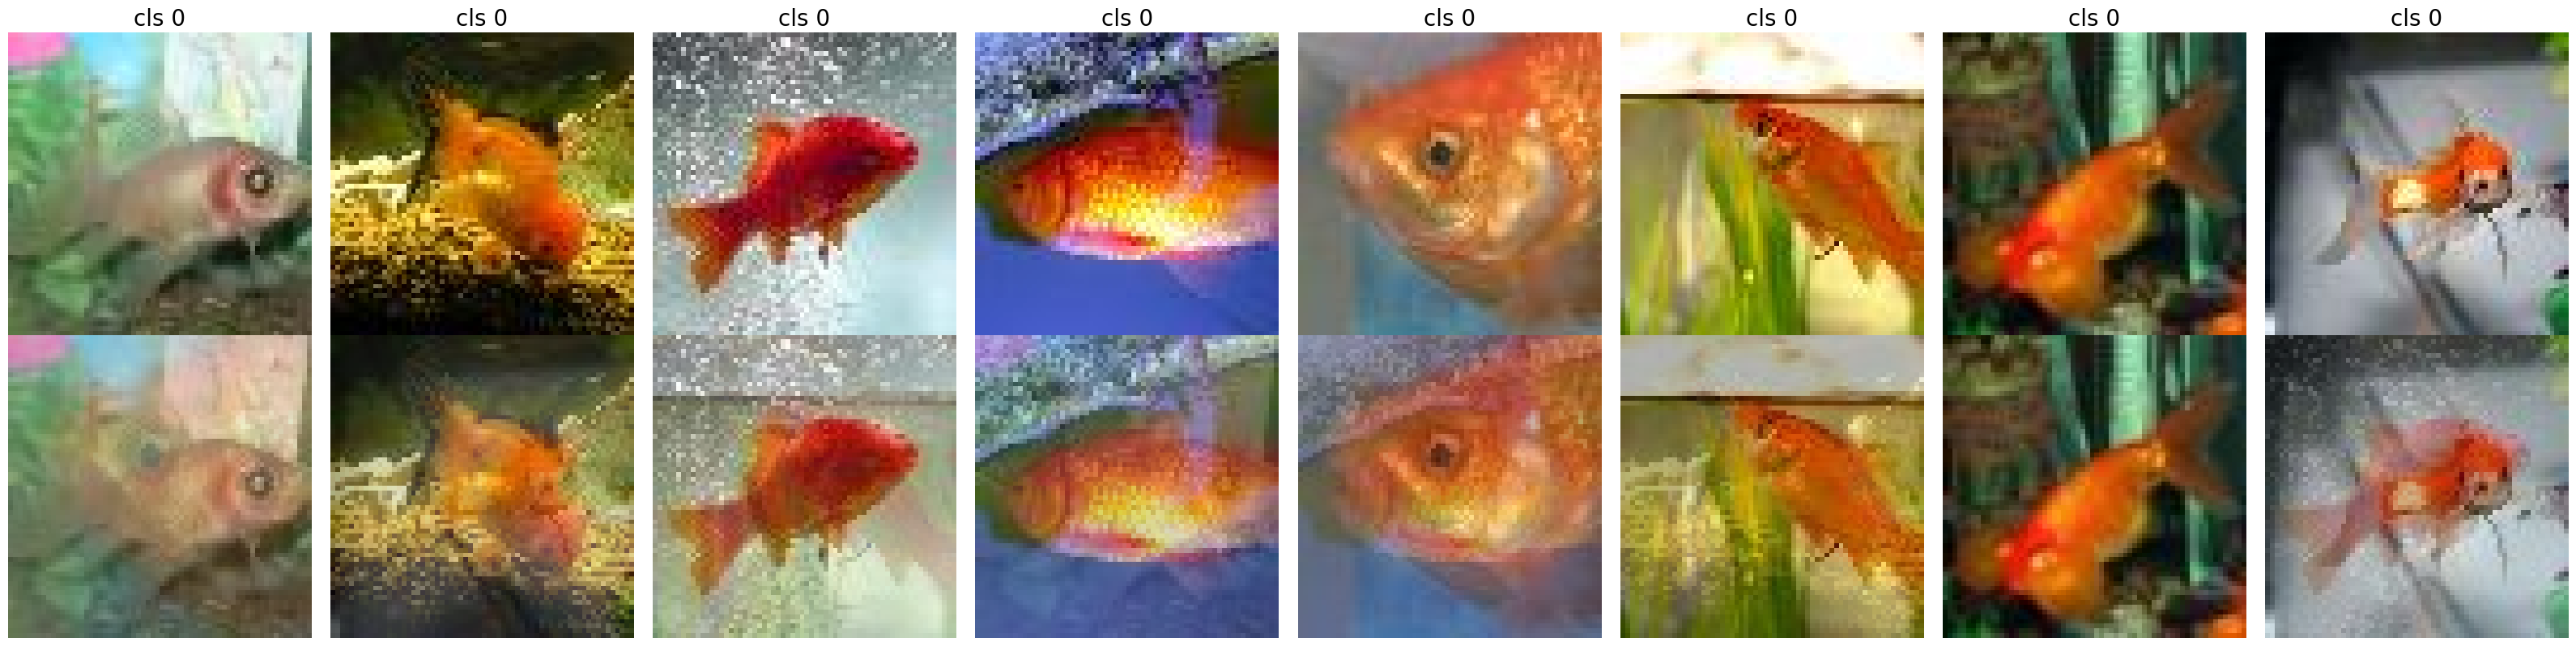

In [10]:
from mlxops_aug import ReMix

remix_aug   = ReMix(num_classes=NUM_CLASSES, config={"prob": 1.0})
remix_aug.setup_based_on_datasets([[None, yy] for yy in targets], None)

x_remix,   y_remix = apply_aug(remix_aug,   x_batch, y_batch)

plot_hor(
    [to_hwc(x_batch),
     to_hwc(x_remix)],
    rows=2, columns=N,
    subplot_titles=col_titles,
    idx=["Original", "ReMix"],
)
print()

## SaliencyMix

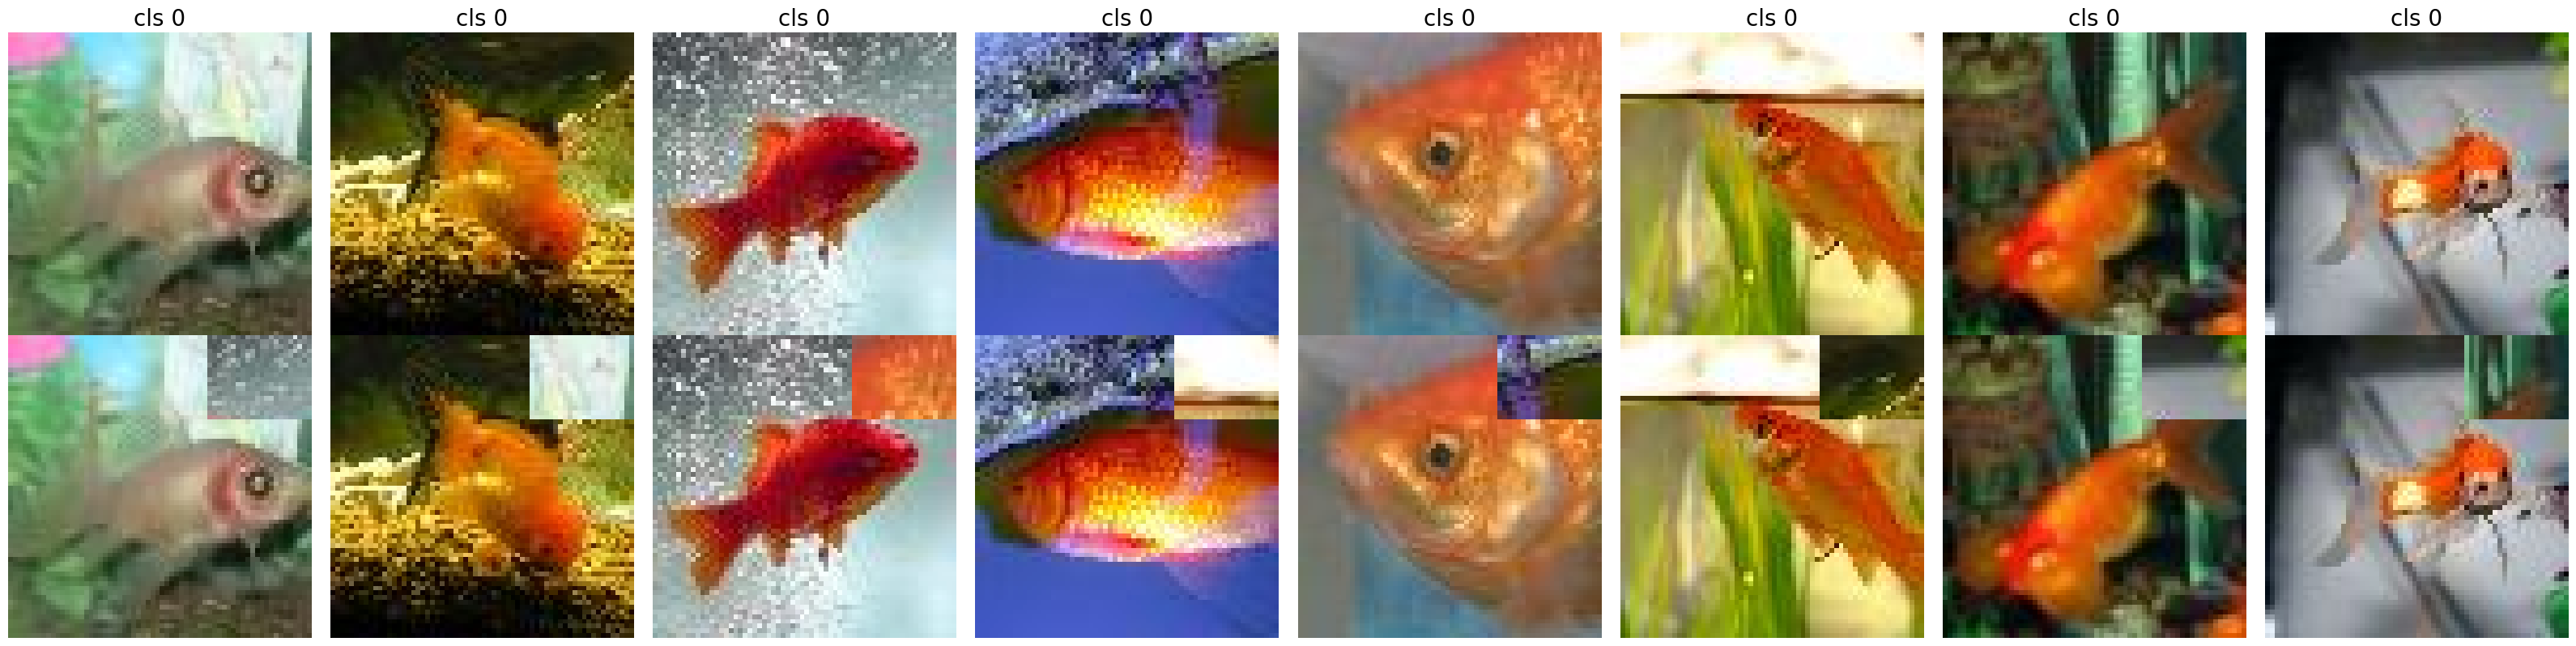

In [11]:
from mlxops_aug import SaliencyMix

saliencymix_aug   = SaliencyMix(num_classes=NUM_CLASSES, config={"prob": 1.0})

x_saliencymix,   y_saliencymix = apply_aug(saliencymix_aug,   x_batch, y_batch)

plot_hor(
    [to_hwc(x_batch),
     to_hwc(x_saliencymix)],
    rows=2, columns=N,
    subplot_titles=col_titles,
    idx=["Original", "SaliencyMix"],
)
print()

## CoMixup

CoMixup Args: namespace(m_part=20, m_block_num=4, m_beta=0.32, m_gamma=1.0, m_thres=0.83, m_thres_type='hard', m_eta=0.05, m_omega=0.001, mixup_alpha=2.0, set_resolve=True, m_niter=1, parallel=False, clean_lam=1.0, num_classes=200)


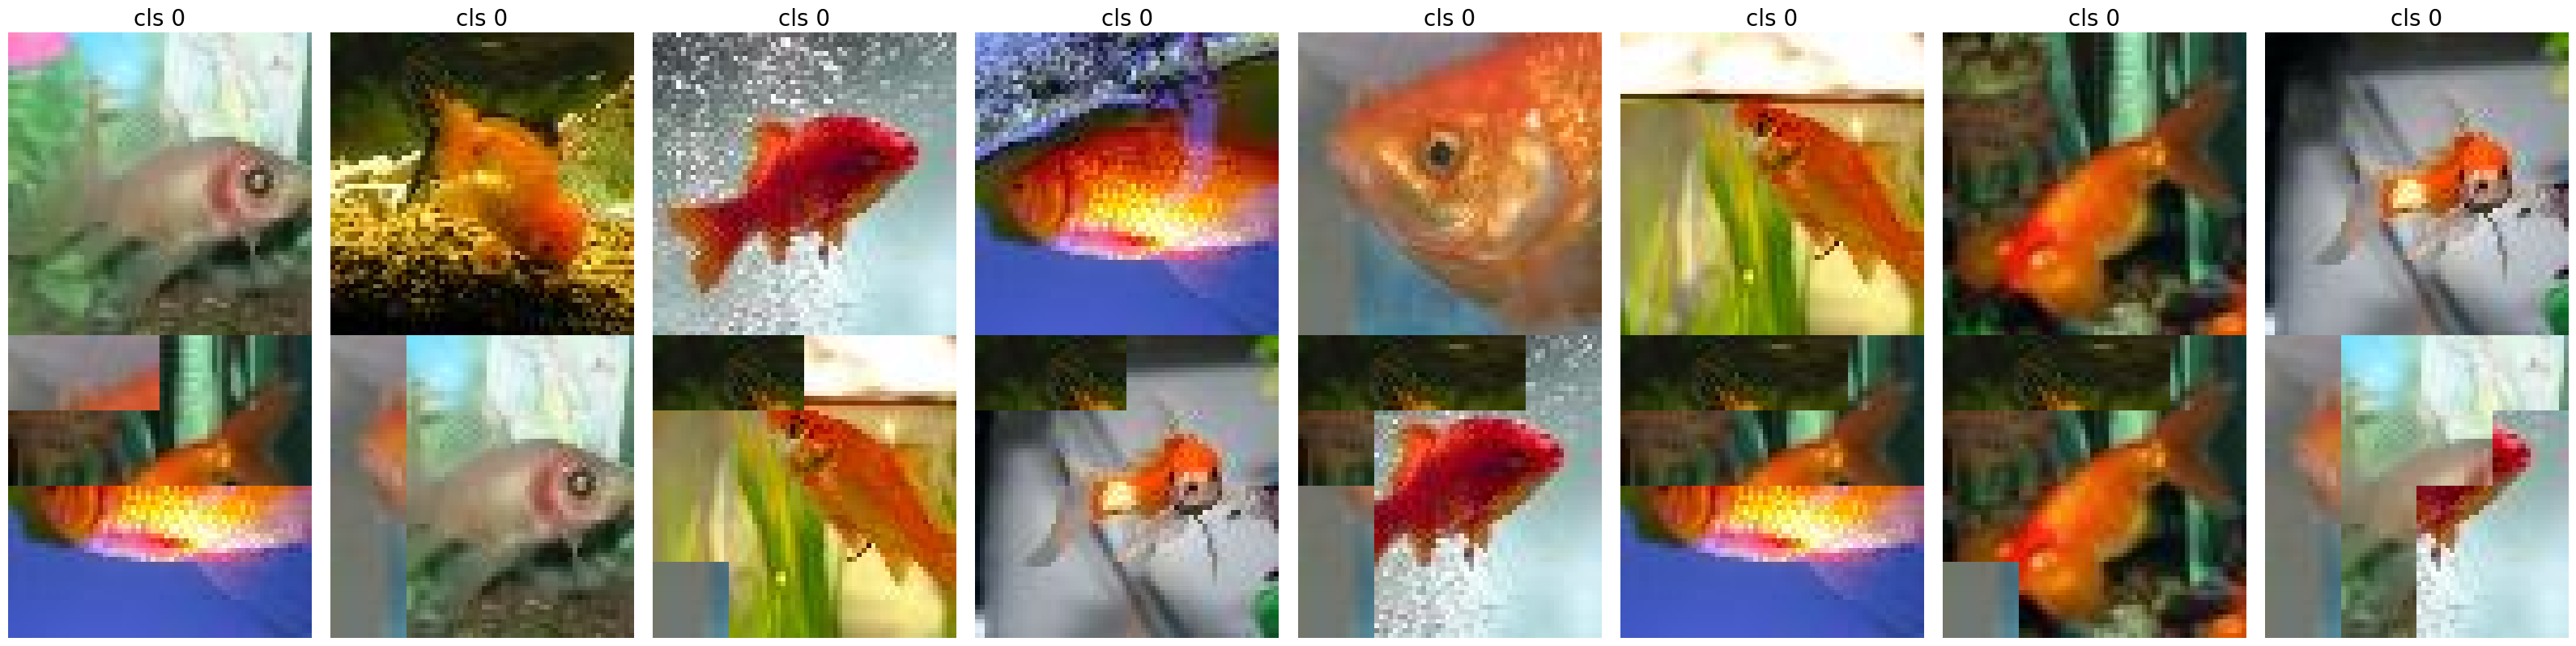

In [12]:
from mlxops_aug import CoMixup

comixup_aug = CoMixup(
    num_classes=NUM_CLASSES,
    config={},
)
spec_device = 'cpu'
backbone = backbone.to(spec_device)
backbone.device = spec_device
comixup_aug.setup_based_on_model(dict(
    training_model=backbone,
    training_optimizer=None
))

ar = comixup_aug(x_batch.to(spec_device), y_batch.to(spec_device))
x_comixup, y = ar.augmented_x, ar.augmented_y

plot_hor(
    [to_hwc(x_batch), to_hwc(x_comixup)],
    rows=2, columns=N,
    subplot_titles=col_titles,
    idx=["Original", "CoMixup"],
)
print()
